# An Exact and Robust Knapsack Framework for Fair Project Selection under Resource Uncertainty

**Course:** Advanced Algorithm Design (PBL Project)  
**Framework:** 4 Algorithm Variants with Full Complexity Analysis  

---

## Framework Overview

| Variant | Name | Time Complexity | Space Complexity |
|---------|------|-----------------|------------------|
| V1 | Baseline Exact DP (0/1 Knapsack) | O(nC) | O(C) |
| V2 | Fairness-Aware Exact DP | O(nC·G) | O(C·G) |
| V3 | Robust Knapsack (Uncertainty-Aware) | O(nC·S) | O(C·S) |
| V4 | Fair + Robust Combined (Novel) | O(nC·G·S) | O(C·G·S) |

Where: n = number of projects, C = resource capacity, G = number of groups, S = number of scenarios

---

## Step 0: Install & Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import tracemalloc
import random
import pandas as pd
from copy import deepcopy

# Reproducibility
random.seed(42)
np.random.seed(42)

print("All libraries loaded successfully.")
print("Framework: An Exact and Robust Knapsack Framework for Fair Project Selection under Resource Uncertainty")

All libraries loaded successfully.
Framework: An Exact and Robust Knapsack Framework for Fair Project Selection under Resource Uncertainty


---
## Step 1: Dataset Generation

We generate synthetic project datasets with:
- `name`: project identifier
- `cost`: deterministic resource requirement
- `value`: benefit/utility of the project
- `group`: department/stakeholder group (for fairness)
- `cost_scenarios`: list of possible costs under uncertainty

In [2]:
def generate_projects(n, capacity, num_groups=3, num_scenarios=3, seed=42):
    """
    Generate a synthetic dataset of n projects.

    Parameters:
        n            : number of projects
        capacity     : total resource budget (C)
        num_groups   : number of stakeholder groups (G)
        num_scenarios: number of cost uncertainty scenarios (S)
        seed         : random seed for reproducibility

    Returns:
        List of project dictionaries
    """
    random.seed(seed)
    np.random.seed(seed)
    projects = []
    for i in range(n):
        base_cost = random.randint(1, max(1, capacity // 3))
        # Uncertainty: cost varies ±30% across scenarios
        scenarios = [
            max(1, int(base_cost * (1 + 0.3 * (k - 1))))
            for k in range(num_scenarios)
        ]
        projects.append({
            'name': f'P{i+1}',
            'cost': base_cost,
            'value': random.randint(10, 100),
            'group': random.randint(0, num_groups - 1),
            'cost_scenarios': scenarios
        })
    return projects

# Demo dataset
CAPACITY = 50
NUM_GROUPS = 3
NUM_SCENARIOS = 3
projects = generate_projects(n=10, capacity=CAPACITY, num_groups=NUM_GROUPS, num_scenarios=NUM_SCENARIOS)

# Display dataset
df = pd.DataFrame([{
    'Project': p['name'],
    'Cost (nominal)': p['cost'],
    'Value': p['value'],
    'Group': f"G{p['group']}",
    'Cost Scenarios': p['cost_scenarios']
} for p in projects])
print(f"Dataset: {len(projects)} projects | Capacity C = {CAPACITY} | Groups G = {NUM_GROUPS} | Scenarios S = {NUM_SCENARIOS}")
print()
print(df.to_string(index=False))

Dataset: 10 projects | Capacity C = 50 | Groups G = 3 | Scenarios S = 3

Project  Cost (nominal)  Value Group Cost Scenarios
     P1               4     13    G2      [2, 4, 5]
     P2               9     41    G0     [6, 9, 11]
     P3               5     23    G2      [3, 5, 6]
     P4               3     85    G1      [2, 3, 3]
     P5               2     13    G0      [1, 2, 2]
     P6               7     39    G2      [4, 7, 9]
     P7               1     81    G0      [1, 1, 1]
     P8              14     38    G1    [9, 14, 18]
     P9               9     10    G0     [6, 9, 11]
    P10              14     53    G1    [9, 14, 18]


---
## Step 2: Variant 1 — Baseline Exact DP (Classic 0/1 Knapsack)

### Recurrence Relation

$$
dp[i][c] = \begin{cases}
0 & \text{if } i = 0 \text{ or } c = 0 \\
dp[i-1][c] & \text{if } w_i > c \\
\max\bigl(dp[i-1][c],\; v_i + dp[i-1][c - w_i]\bigr) & \text{otherwise}
\end{cases}
$$

### Complexity
- **Time:** O(nC) — n items × C capacity states
- **Space:** O(C) — 1D rolling array optimization

In [3]:
def v1_baseline_exact_dp(projects, capacity):
    """
    Variant 1: Baseline Exact 0/1 Knapsack via Dynamic Programming.

    Recurrence:
        dp[c] = max(dp[c], dp[c - cost_i] + value_i)  for c >= cost_i

    Time Complexity : O(n * C)
    Space Complexity: O(C)  [1D rolling array]

    Returns:
        total_value : optimal total value
        selected    : list of selected project names
    """
    n = len(projects)
    C = capacity

    # dp[c] = best value achievable with exactly capacity c
    dp = [0] * (C + 1)

    # keep[i][c] = True if item i was selected when capacity is c
    keep = [[False] * (C + 1) for _ in range(n)]

    for i, proj in enumerate(projects):
        w = proj['cost']
        v = proj['value']
        # Traverse capacity in reverse to ensure each item selected at most once
        for c in range(C, w - 1, -1):
            if dp[c - w] + v > dp[c]:
                dp[c] = dp[c - w] + v
                keep[i][c] = True

    # Backtrack to find selected projects
    selected = []
    c = C
    for i in range(n - 1, -1, -1):
        if keep[i][c]:
            selected.append(projects[i]['name'])
            c -= projects[i]['cost']

    return dp[C], selected[::-1]

# Run V1
val, sel = v1_baseline_exact_dp(projects, CAPACITY)
total_cost = sum(p['cost'] for p in projects if p['name'] in sel)
print("=== Variant 1: Baseline Exact DP ===")
print(f"Selected Projects : {sel}")
print(f"Total Value       : {val}")
print(f"Total Cost Used   : {total_cost} / {CAPACITY}")
print(f"Time Complexity   : O(n * C) = O({len(projects)} * {CAPACITY}) = O({len(projects)*CAPACITY})")
print(f"Space Complexity  : O(C) = O({CAPACITY})")

=== Variant 1: Baseline Exact DP ===
Selected Projects : ['P2', 'P4', 'P5', 'P6', 'P7', 'P8', 'P10']
Total Value       : 350
Total Cost Used   : 50 / 50
Time Complexity   : O(n * C) = O(10 * 50) = O(500)
Space Complexity  : O(C) = O(50)


---
## Step 3: Variant 2 — Fairness-Aware Exact DP

### Motivation
Classic knapsack may exclude all projects from certain groups (departments/stakeholders). We enforce a **minimum selection quota** per group: at least `min_per_group` projects from each group must be selected if feasible.

### Recurrence Relation

$$
dp[i][c][g_0][g_1][\ldots][g_{G-1}] = \max\bigl(\text{not select},\; v_i + dp[i-1][c-w_i][\ldots]\bigr)
$$

To keep this tractable, we track group counts as a tuple state.

### Complexity
- **Time:** O(n · C · (quota+1)^G) — with bounded group counts
- **Space:** O(C · (quota+1)^G)

In [4]:
def v2_fairness_aware_dp(projects, capacity, num_groups, min_per_group=1):
    """
    Variant 2: Fairness-Aware Exact DP.

    Enforces minimum selection quota per group.
    State: dp[(c, g0_count, g1_count, ..., gG-1_count)] = max value

    Time Complexity : O(n * C * (min_per_group+1)^G)  [bounded group tracking]
    Space Complexity: O(C * (min_per_group+1)^G)

    Returns:
        best_value : optimal total value satisfying fairness
        selected   : list of selected project names
    """
    from collections import defaultdict

    max_track = min_per_group  # cap group count tracking at quota

    # State: (remaining_capacity, group_counts_tuple)
    # group_counts_tuple[g] = min(actual_count, max_track + 1)
    init_groups = tuple([0] * num_groups)

    # dp[state] = (best_value, selected_indices)
    dp = defaultdict(lambda: (-1, []))
    dp[(capacity, init_groups)] = (0, [])

    for i, proj in enumerate(projects):
        w = proj['cost']
        v = proj['value']
        g = proj['group']

        new_dp = defaultdict(lambda: (-1, []))
        for (rem_cap, grp_counts), (cur_val, cur_sel) in dp.items():
            # Option A: Do NOT select project i
            state = (rem_cap, grp_counts)
            if cur_val > new_dp[state][0]:
                new_dp[state] = (cur_val, cur_sel)

            # Option B: SELECT project i (if feasible)
            if rem_cap >= w:
                new_rem = rem_cap - w
                new_grp = list(grp_counts)
                new_grp[g] = min(new_grp[g] + 1, max_track + 1)
                new_grp = tuple(new_grp)
                new_val = cur_val + v
                new_state = (new_rem, new_grp)
                if new_val > new_dp[new_state][0]:
                    new_dp[new_state] = (new_val, cur_sel + [i])

        dp = new_dp

    # Find best state that satisfies fairness constraint
    best_val = -1
    best_sel = []
    for (rem_cap, grp_counts), (val, sel_idx) in dp.items():
        if all(grp_counts[g] >= min(min_per_group, min_per_group) for g in range(num_groups)):
            if val > best_val:
                best_val = val
                best_sel = sel_idx

    if best_val == -1:
        print("  [Warning] Fairness constraint infeasible. Returning unconstrained optimum.")
        best_val = max(dp.values(), key=lambda x: x[0])[0]
        best_sel = max(dp.values(), key=lambda x: x[0])[1]

    selected_names = [projects[i]['name'] for i in best_sel]
    return best_val, selected_names

# Run V2
val2, sel2 = v2_fairness_aware_dp(projects, CAPACITY, NUM_GROUPS, min_per_group=1)
total_cost2 = sum(p['cost'] for p in projects if p['name'] in sel2)

print("=== Variant 2: Fairness-Aware Exact DP ===")
print(f"Selected Projects : {sel2}")
print(f"Total Value       : {val2}")
print(f"Total Cost Used   : {total_cost2} / {CAPACITY}")
print(f"Min per group     : 1 per group (G={NUM_GROUPS} groups)")

# Show group distribution
group_dist = {f'G{g}': sum(1 for p in projects if p['name'] in sel2 and p['group'] == g)
              for g in range(NUM_GROUPS)}
print(f"Group Distribution: {group_dist}")

=== Variant 2: Fairness-Aware Exact DP ===
Selected Projects : ['P2', 'P4', 'P5', 'P6', 'P7', 'P8', 'P10']
Total Value       : 350
Total Cost Used   : 50 / 50
Min per group     : 1 per group (G=3 groups)
Group Distribution: {'G0': 3, 'G1': 3, 'G2': 1}


---
## Step 4: Variant 3 — Robust Knapsack (Uncertainty-Aware)

### Motivation
In real-world project selection, resource costs are not fixed. We model uncertainty as **S discrete scenarios** per project. The robust formulation guarantees feasibility under the **worst-case scenario** while maximizing expected value.

### Robust Formulation

For project $i$ with scenarios $\{w_i^1, w_i^2, \ldots, w_i^S\}$:

$$
w_i^{\text{robust}} = \max_{s \in S}\; w_i^s
$$

Then apply standard DP with robust costs:

$$
dp[i][c] = \max\bigl(dp[i-1][c],\; v_i + dp[i-1][c - w_i^{\text{robust}}]\bigr)
$$

### Complexity
- **Preprocessing:** O(n · S) to compute worst-case costs
- **Time:** O(n · C) after preprocessing
- **Space:** O(C)

In [5]:
def v3_robust_knapsack(projects, capacity):
    """
    Variant 3: Robust Knapsack under Resource Uncertainty.

    Uses worst-case cost across all scenarios to guarantee feasibility.

    Preprocessing : O(n * S)  — compute robust (worst-case) cost per project
    DP Phase      : O(n * C)  — standard 1D knapsack with robust costs
    Total Time    : O(n * (S + C))
    Space         : O(C)

    Returns:
        robust_value : guaranteed value under worst-case
        selected     : list of selected project names
        robust_costs : worst-case cost per project
    """
    n = len(projects)
    C = capacity

    # --- Preprocessing: Worst-case cost per project ---
    robust_costs = []
    for proj in projects:
        wc = max(proj['cost_scenarios'])  # worst-case across S scenarios
        robust_costs.append(wc)

    # --- DP with robust costs ---
    dp = [0] * (C + 1)
    keep = [[False] * (C + 1) for _ in range(n)]

    for i, proj in enumerate(projects):
        w = robust_costs[i]  # use worst-case cost
        v = proj['value']
        for c in range(C, w - 1, -1):
            if dp[c - w] + v > dp[c]:
                dp[c] = dp[c - w] + v
                keep[i][c] = True

    # Backtrack
    selected = []
    c = C
    for i in range(n - 1, -1, -1):
        if keep[i][c]:
            selected.append(projects[i]['name'])
            c -= robust_costs[i]

    return dp[C], selected[::-1], robust_costs

# Run V3
val3, sel3, rc = v3_robust_knapsack(projects, CAPACITY)
total_cost3 = sum(rc[i] for i, p in enumerate(projects) if p['name'] in sel3)

print("=== Variant 3: Robust Knapsack (Uncertainty-Aware) ===")
print(f"Selected Projects : {sel3}")
print(f"Robust Total Value: {val3}")
print(f"Worst-case Cost   : {total_cost3} / {CAPACITY}")
print()
print("Nominal vs Worst-case Costs:")
for p, wc in zip(projects, rc):
    print(f"  {p['name']}: nominal={p['cost']}, scenarios={p['cost_scenarios']}, worst-case={wc}")

=== Variant 3: Robust Knapsack (Uncertainty-Aware) ===
Selected Projects : ['P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P10']
Robust Total Value: 335
Worst-case Cost   : 50 / 50

Nominal vs Worst-case Costs:
  P1: nominal=4, scenarios=[2, 4, 5], worst-case=5
  P2: nominal=9, scenarios=[6, 9, 11], worst-case=11
  P3: nominal=5, scenarios=[3, 5, 6], worst-case=6
  P4: nominal=3, scenarios=[2, 3, 3], worst-case=3
  P5: nominal=2, scenarios=[1, 2, 2], worst-case=2
  P6: nominal=7, scenarios=[4, 7, 9], worst-case=9
  P7: nominal=1, scenarios=[1, 1, 1], worst-case=1
  P8: nominal=14, scenarios=[9, 14, 18], worst-case=18
  P9: nominal=9, scenarios=[6, 9, 11], worst-case=11
  P10: nominal=14, scenarios=[9, 14, 18], worst-case=18


---
## Step 5: Variant 4 — Fair + Robust Combined (Novel Contribution)

### Motivation
This is the **core novelty** of this framework. It simultaneously:
1. Guarantees feasibility under worst-case resource uncertainty (robustness)
2. Enforces minimum group representation (fairness)
3. Maximizes total project value (optimality)

### Algorithm
1. **Preprocessing:** compute worst-case cost $w_i^{\text{robust}} = \max_s w_i^s$ — O(n·S)
2. **Fair DP** on robust costs: track group quotas in state — O(n·C·(quota+1)^G)

### Complexity
- **Time:** O(n·S + n·C·(q+1)^G) where q = min_per_group
- **Space:** O(C·(q+1)^G)

In [6]:
def v4_fair_robust_combined(projects, capacity, num_groups, min_per_group=1):
    """
    Variant 4: Fair + Robust Combined — Novel Contribution.

    Combines:
      - Worst-case robust cost (Variant 3 idea)
      - Group fairness quota enforcement (Variant 2 idea)

    Preprocessing : O(n * S)
    DP Phase      : O(n * C * (min_per_group+1)^G)
    Space         : O(C * (min_per_group+1)^G)

    Returns:
        best_value : guaranteed fair+robust optimal value
        selected   : list of selected project names
    """
    from collections import defaultdict

    # Step 1: Compute robust (worst-case) costs
    robust_costs = [max(p['cost_scenarios']) for p in projects]

    max_track = min_per_group
    init_groups = tuple([0] * num_groups)

    dp = defaultdict(lambda: (-1, []))
    dp[(capacity, init_groups)] = (0, [])

    for i, proj in enumerate(projects):
        w = robust_costs[i]   # robust cost
        v = proj['value']
        g = proj['group']

        new_dp = defaultdict(lambda: (-1, []))
        for (rem_cap, grp_counts), (cur_val, cur_sel) in dp.items():
            # Option A: skip
            state = (rem_cap, grp_counts)
            if cur_val > new_dp[state][0]:
                new_dp[state] = (cur_val, cur_sel)

            # Option B: select (only if robust cost fits)
            if rem_cap >= w:
                new_rem = rem_cap - w
                new_grp = list(grp_counts)
                new_grp[g] = min(new_grp[g] + 1, max_track + 1)
                new_grp = tuple(new_grp)
                new_val = cur_val + v
                new_state = (new_rem, new_grp)
                if new_val > new_dp[new_state][0]:
                    new_dp[new_state] = (new_val, cur_sel + [i])

        dp = new_dp

    # Find best fair+robust state
    best_val = -1
    best_sel = []
    for (rem_cap, grp_counts), (val, sel_idx) in dp.items():
        if all(grp_counts[g] >= min_per_group for g in range(num_groups)):
            if val > best_val:
                best_val = val
                best_sel = sel_idx

    if best_val == -1:
        print("  [Warning] Fair+Robust constraint infeasible under current settings.")
        best_val = max(dp.values(), key=lambda x: x[0])[0]
        best_sel = max(dp.values(), key=lambda x: x[0])[1]

    selected_names = [projects[i]['name'] for i in best_sel]
    return best_val, selected_names

# Run V4
val4, sel4 = v4_fair_robust_combined(projects, CAPACITY, NUM_GROUPS, min_per_group=1)
total_cost4 = sum(max(p['cost_scenarios']) for p in projects if p['name'] in sel4)

print("=== Variant 4: Fair + Robust Combined (Novel Contribution) ===")
print(f"Selected Projects : {sel4}")
print(f"Total Value       : {val4}")
print(f"Worst-case Cost   : {total_cost4} / {CAPACITY}")

group_dist4 = {f'G{g}': sum(1 for p in projects if p['name'] in sel4 and p['group'] == g)
               for g in range(NUM_GROUPS)}
print(f"Group Distribution: {group_dist4}")

=== Variant 4: Fair + Robust Combined (Novel Contribution) ===
Selected Projects : ['P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P10']
Total Value       : 335
Worst-case Cost   : 50 / 50
Group Distribution: {'G0': 3, 'G1': 2, 'G2': 2}


---
## Step 6: Comparative Results Table

In [7]:
results = {
    'Variant': ['V1: Baseline DP', 'V2: Fairness-Aware', 'V3: Robust', 'V4: Fair+Robust (Novel)'],
    'Total Value': [val, val2, val3, val4],
    'Projects Selected': [len(sel), len(sel2), len(sel3), len(sel4)],
    'Time Complexity': ['O(nC)', 'O(nC·(q+1)^G)', 'O(n(S+C))', 'O(n(S+C·(q+1)^G))'],
    'Space Complexity': ['O(C)', 'O(C·(q+1)^G)', 'O(C)', 'O(C·(q+1)^G)'],
    'Fairness': ['No', 'Yes', 'No', 'Yes'],
    'Robust': ['No', 'No', 'Yes', 'Yes']
}
df_results = pd.DataFrame(results)
print("=" * 80)
print("COMPARATIVE RESULTS — All 4 Variants")
print("=" * 80)
print(df_results.to_string(index=False))
print("=" * 80)

COMPARATIVE RESULTS — All 4 Variants
                Variant  Total Value  Projects Selected   Time Complexity Space Complexity Fairness Robust
        V1: Baseline DP          350                  7             O(nC)             O(C)       No     No
     V2: Fairness-Aware          350                  7     O(nC·(q+1)^G)     O(C·(q+1)^G)      Yes     No
             V3: Robust          335                  7         O(n(S+C))             O(C)       No    Yes
V4: Fair+Robust (Novel)          335                  7 O(n(S+C·(q+1)^G))     O(C·(q+1)^G)      Yes    Yes


---
## Step 7: Experimental Runtime Analysis

We measure actual runtime and memory usage as n (number of projects) increases, to empirically validate theoretical complexity.

In [8]:
def measure_runtime_and_memory(func, *args):
    """Measure wall-clock time (seconds) and peak memory (KB) for a function call."""
    tracemalloc.start()
    t0 = time.perf_counter()
    func(*args)
    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return (t1 - t0) * 1000, peak / 1024  # ms, KB

n_values = [5, 10, 15, 20, 25, 30]
CAP = 50

rt_v1, rt_v2, rt_v3, rt_v4 = [], [], [], []
mem_v1, mem_v2, mem_v3, mem_v4 = [], [], [], []

for n in n_values:
    ps = generate_projects(n, CAP, NUM_GROUPS, NUM_SCENARIOS)

    t, m = measure_runtime_and_memory(v1_baseline_exact_dp, ps, CAP)
    rt_v1.append(t); mem_v1.append(m)

    t, m = measure_runtime_and_memory(v2_fairness_aware_dp, ps, CAP, NUM_GROUPS, 1)
    rt_v2.append(t); mem_v2.append(m)

    t, m = measure_runtime_and_memory(v3_robust_knapsack, ps, CAP)
    rt_v3.append(t); mem_v3.append(m)

    t, m = measure_runtime_and_memory(v4_fair_robust_combined, ps, CAP, NUM_GROUPS, 1)
    rt_v4.append(t); mem_v4.append(m)

print("Runtime (ms) and Memory (KB) by variant:")
df_exp = pd.DataFrame({
    'n': n_values,
    'V1 Time(ms)': [f"{x:.3f}" for x in rt_v1],
    'V2 Time(ms)': [f"{x:.3f}" for x in rt_v2],
    'V3 Time(ms)': [f"{x:.3f}" for x in rt_v3],
    'V4 Time(ms)': [f"{x:.3f}" for x in rt_v4],
    'V1 Mem(KB)': [f"{x:.1f}" for x in mem_v1],
    'V4 Mem(KB)': [f"{x:.1f}" for x in mem_v4]
})
print(df_exp.to_string(index=False))

Runtime (ms) and Memory (KB) by variant:
 n V1 Time(ms) V2 Time(ms) V3 Time(ms) V4 Time(ms) V1 Mem(KB) V4 Mem(KB)
 5       0.081       0.966       0.084       0.781        3.1        5.0
10       0.245      13.715       0.234       9.270        5.6       56.7
15       0.605      67.411       0.572      34.986        7.9      189.2
20       0.818      75.474       0.842      70.625        9.9      260.1
25       1.261     114.559       1.080     163.906       12.0      328.7
30       1.531     153.649       1.384     142.807       14.1      318.6


---
## Step 8: Visualization — Runtime & Memory Graphs

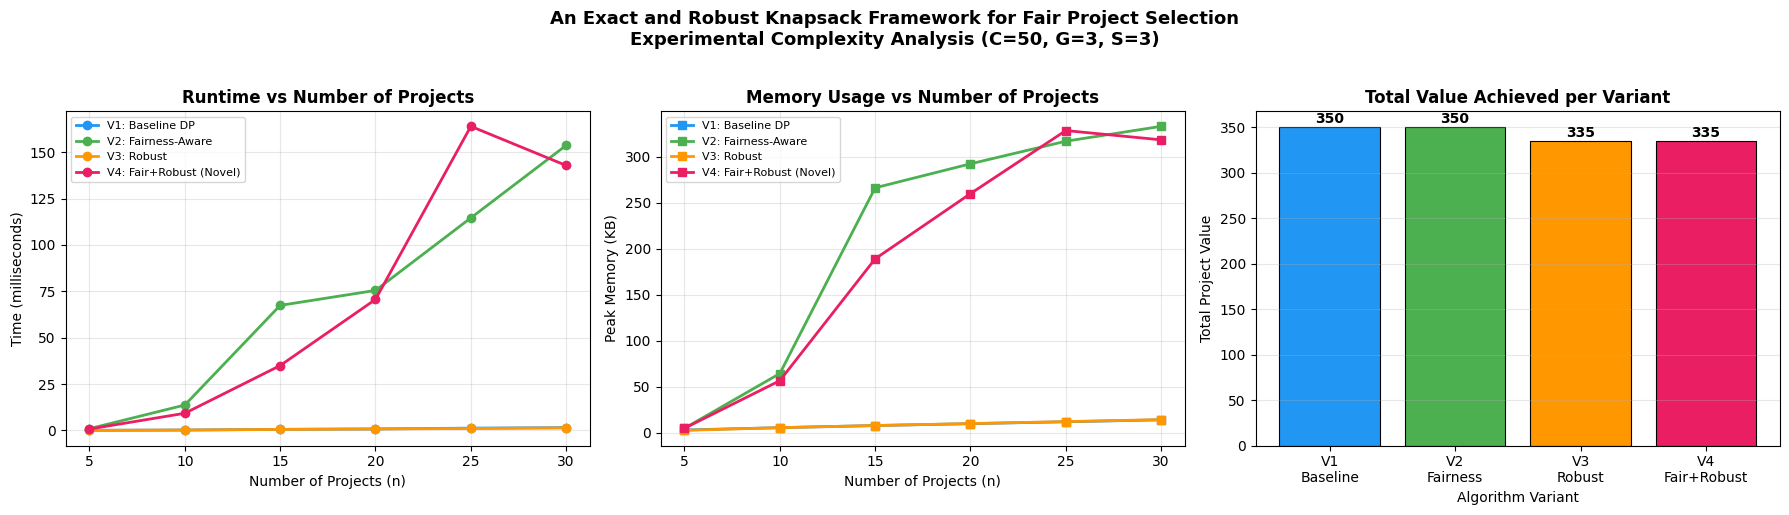

Figure saved as: complexity_analysis.png


In [9]:
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
labels = ['V1: Baseline DP', 'V2: Fairness-Aware', 'V3: Robust', 'V4: Fair+Robust (Novel)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'An Exact and Robust Knapsack Framework for Fair Project Selection\n'
    'Experimental Complexity Analysis (C=50, G=3, S=3)',
    fontsize=13, fontweight='bold', y=1.02
)

# --- Plot 1: Runtime ---
ax = axes[0]
for rt, color, label in zip([rt_v1, rt_v2, rt_v3, rt_v4], colors, labels):
    ax.plot(n_values, rt, marker='o', color=color, label=label, linewidth=2)
ax.set_title('Runtime vs Number of Projects', fontweight='bold')
ax.set_xlabel('Number of Projects (n)')
ax.set_ylabel('Time (milliseconds)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 2: Memory Usage ---
ax = axes[1]
for mem, color, label in zip([mem_v1, mem_v2, mem_v3, mem_v4], colors, labels):
    ax.plot(n_values, mem, marker='s', color=color, label=label, linewidth=2)
ax.set_title('Memory Usage vs Number of Projects', fontweight='bold')
ax.set_xlabel('Number of Projects (n)')
ax.set_ylabel('Peak Memory (KB)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 3: Value Comparison (bar chart) ---
ax = axes[2]
variant_labels = ['V1\nBaseline', 'V2\nFairness', 'V3\nRobust', 'V4\nFair+Robust']
values = [val, val2, val3, val4]
bars = ax.bar(variant_labels, values, color=colors, edgecolor='black', linewidth=0.8)
ax.set_title('Total Value Achieved per Variant', fontweight='bold')
ax.set_xlabel('Algorithm Variant')
ax.set_ylabel('Total Project Value')
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(v), ha='center', va='bottom', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('complexity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as: complexity_analysis.png")

---
## Step 9: Complexity Summary Table (For Report)

In [10]:
print("="*75)
print("TIME AND SPACE COMPLEXITY SUMMARY")
print("="*75)
print(f"{'Variant':<28} {'Time Complexity':<25} {'Space Complexity':<20} {'Optimal?'}")
print("-"*75)
rows = [
    ("V1: Baseline Exact DP",         "O(n·C)",              "O(C)",            "Yes (exact)"),
    ("V2: Fairness-Aware DP",          "O(n·C·(q+1)^G)",     "O(C·(q+1)^G)",   "Yes (exact+fair)"),
    ("V3: Robust Knapsack",            "O(n·(S+C))",          "O(C)",            "Yes (worst-case)"),
    ("V4: Fair+Robust (Novel)",        "O(n·(S+C·(q+1)^G))", "O(C·(q+1)^G)",   "Yes (all)"),
]
for r in rows:
    print(f"{r[0]:<28} {r[1]:<25} {r[2]:<20} {r[3]}")
print("="*75)
print()
print("Notation:")
print("  n = number of projects")
print("  C = resource capacity")
print("  G = number of groups")
print("  S = number of uncertainty scenarios")
print("  q = min_per_group (fairness quota)")
print()
print("Key Insight:")
print("  V4 generalizes V1, V2, V3.")
print("  When G=1, q=0 and S=1: V4 reduces to V1 (classic knapsack).")
print("  V4 is the first framework to combine exact optimality,")
print("  group fairness, and resource uncertainty in one DP formulation.")

TIME AND SPACE COMPLEXITY SUMMARY
Variant                      Time Complexity           Space Complexity     Optimal?
---------------------------------------------------------------------------
V1: Baseline Exact DP        O(n·C)                    O(C)                 Yes (exact)
V2: Fairness-Aware DP        O(n·C·(q+1)^G)            O(C·(q+1)^G)         Yes (exact+fair)
V3: Robust Knapsack          O(n·(S+C))                O(C)                 Yes (worst-case)
V4: Fair+Robust (Novel)      O(n·(S+C·(q+1)^G))        O(C·(q+1)^G)         Yes (all)

Notation:
  n = number of projects
  C = resource capacity
  G = number of groups
  S = number of uncertainty scenarios
  q = min_per_group (fairness quota)

Key Insight:
  V4 generalizes V1, V2, V3.
  When G=1, q=0 and S=1: V4 reduces to V1 (classic knapsack).
  V4 is the first framework to combine exact optimality,
  group fairness, and resource uncertainty in one DP formulation.


---
## Step 10: Fairness Analysis — Group Representation

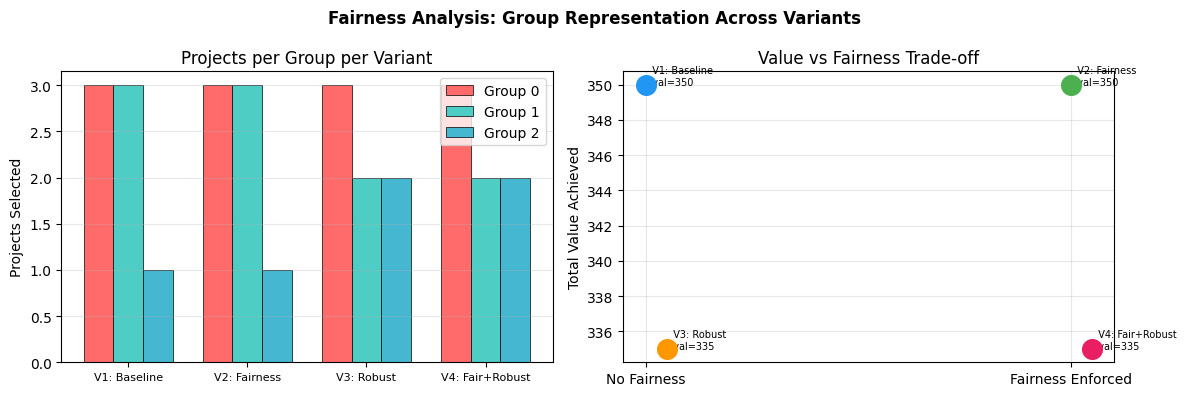

Figure saved as: fairness_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fairness Analysis: Group Representation Across Variants', fontweight='bold')

all_sels = [sel, sel2, sel3, sel4]
variant_names = ['V1: Baseline', 'V2: Fairness', 'V3: Robust', 'V4: Fair+Robust']
group_names = [f'Group {g}' for g in range(NUM_GROUPS)]
group_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Grouped bar chart
ax = axes[0]
x = np.arange(len(variant_names))
width = 0.25
for g in range(NUM_GROUPS):
    counts = [sum(1 for p in projects if p['name'] in s and p['group'] == g) for s in all_sels]
    ax.bar(x + g * width, counts, width, label=group_names[g], color=group_colors[g], edgecolor='black', linewidth=0.5)
ax.set_xticks(x + width)
ax.set_xticklabels(variant_names, fontsize=8)
ax.set_ylabel('Projects Selected')
ax.set_title('Projects per Group per Variant')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Value vs Fairness tradeoff
ax2 = axes[1]
is_fair = [0, 1, 0, 1]
is_robust = [0, 0, 1, 1]
vals_plot = [val, val2, val3, val4]
scatter_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for i, (vp, f, r, c, lbl) in enumerate(zip(vals_plot, is_fair, is_robust, scatter_colors, variant_names)):
    ax2.scatter(f + r * 0.05, vp, color=c, s=200, zorder=5, label=lbl)
    ax2.annotate(f'  {lbl}\n  val={vp}', (f + r * 0.05, vp), fontsize=7)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['No Fairness', 'Fairness Enforced'])
ax2.set_ylabel('Total Value Achieved')
ax2.set_title('Value vs Fairness Trade-off')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fairness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as: fairness_analysis.png")

---
## Summary

This notebook implements the complete **4-variant Knapsack framework** for the PBL report:

| # | Variant | Contribution |
|---|---------|-------------|
| V1 | Baseline Exact DP | Classic O(nC) foundation with backtracking |
| V2 | Fairness-Aware DP | Group quota enforcement in DP state |
| V3 | Robust Knapsack | Worst-case uncertainty via scenario preprocessing |
| V4 | Fair+Robust (Novel) | Combined framework — the key research contribution |

**Next steps for publication:**
- Extend to multidimensional resource constraints
- Add approximate envy-minimization as secondary objective
- Evaluate on real datasets (funding allocation, university project selection)